# Análisis Black Friday

In [1]:
#Importamos las librerías necesarias inicialmente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  Lectura de datasets

El data set se ha obtenido de Kaggle: https://www.kaggle.com/datasets/rajeshrampure/black-friday-sale

#### Detalles del Dataset

Empresa de retail "ABC Private Limited" tiene la intención de comprender el comportamiento de compra de los cosnumidores durante la semana que dura este evento. 

El data set contiene las siguiente información demográfica de los clientes: 

1. ID_Usuario
2. ID_Producto
3. Género (sexo: femenino y masculino)
4. Edad: Por rangos de edad desde los 0 a +55
5. Estado civil: casado (1) soltero (0)
6. Ocupación: por números se denominan las profesiones, que irian de 0 a 20 enumeradas, aunque se desconoce a que profesiones hace alusion.
7. Categoria de ciudad: A - Alta categoria; B - Categoria media ; C - Baja Categoria
8. Años de permanencia en la ciudad actual: 0 a +4 años
9. Producto_Categoria_1
10. Producto_Categoria_2
11. Producto_Categoria_3
12. Compra: "Purchase" - Cantidad de compras


In [2]:
blackfriday=pd.read_csv(r'Black Friday Dataset.csv')

In [3]:
blackfriday.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [4]:
blackfriday.describe(include = 'all')

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068,550068,550068,550068.000000,550068,550068,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
unique,NaN,3631,2,7,NaN,3,5,NaN,NaN,NaN,NaN,NaN
top,NaN,P00265242,M,26-35,NaN,B,1,NaN,NaN,NaN,NaN,NaN
freq,NaN,1880,414259,219587,NaN,231173,193821,NaN,NaN,NaN,NaN,NaN
mean,1.003029e+06,NaN,NaN,NaN,8.076707,NaN,NaN,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,NaN,NaN,NaN,6.522660,NaN,NaN,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,NaN,NaN,NaN,2.000000,NaN,NaN,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,NaN,NaN,NaN,7.000000,NaN,NaN,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,NaN,NaN,NaN,14.000000,NaN,NaN,1.000000,8.000000,15.000000,16.000000,12054.000000


#### Correcciones y limpieza del data set

Debemos asegurar que los datos contenidos en el data set son totalmente claros.Por lo que se debe primero lo que contiene el cvs, si exiten datos de poco valor o nulos o duplicidades de estos.

#### Información del data set

In [5]:
blackfriday.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  str    
 2   Gender                      550068 non-null  str    
 3   Age                         550068 non-null  str    
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  str    
 6   Stay_In_Current_City_Years  550068 non-null  str    
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 50.4 MB


#### Contenido DataSet
1. El total de datos introducidos en el dataset son 550068.
2. Hay 12 variables.
3. Los productos 2 y 3 tienen valores nulos o no tienen datos. Sus valores son de tipo "float".
4. El resto de variables son de tipo int y objeto


#### Valores nulos o incorrectos

Vamos a intentar remplazar los valores nulos o vacios de los Productos 2 y 3.


In [6]:
#1-Ver cuantos valors nulos hay en cada variable
blackfriday.isnull().sum()


User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [7]:
#2- Averiguar los valores que faltan y replazarlos por 0
blackfriday.fillna(0,inplace=True)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,0.0,0.0,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,0.0,0.0,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,0.0,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,0.0,0.0,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,0.0,0.0,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,0.0,0.0,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,0.0,0.0,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,0.0,0.0,365


In [8]:
# 3- Revisar si el dataset contiene datos duplicados
sum(blackfriday.duplicated())

0

Como podemos observar el siguiente dataset contiene 12 variables que se pueden analizar a través de una serie de preguntas que nos permita explicar mejor la informacion que contiene el dataset.

PREGUNTAS
1. Influye el género en la cantidad de compras
2. La edad como factor de influencia en la cantidad de compras
3. La categoría de la ciudad inlfuye en las compras y en los tipos de compra
4. El estado civil como factor condicional de la cantidad de compras


 # Gráfico 1: Cantidad de compras por categoría 1

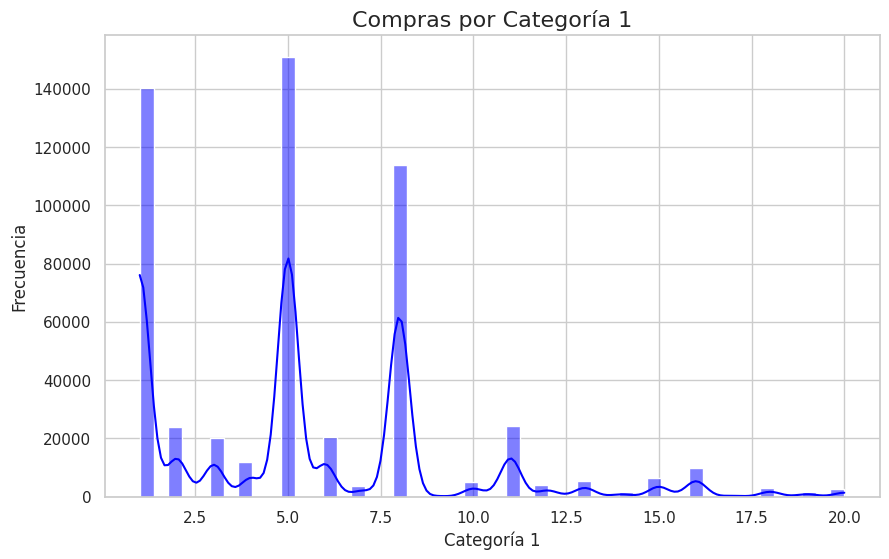

In [9]:
# Configurar estilo de gráficos
sns.set(style="whitegrid")

# Cargar el dataset
data = pd.read_csv("Black Friday Dataset.csv")
# --- Gráfico 1: Cantidad de compras según su frecuencia ---
plt.figure(figsize=(10, 6))
sns.histplot(data['Product_Category_1'], kde=True, bins=50, color='blue')
plt.title('Compras por Categoría 1', fontsize=16)
plt.xlabel('Categoría 1', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()


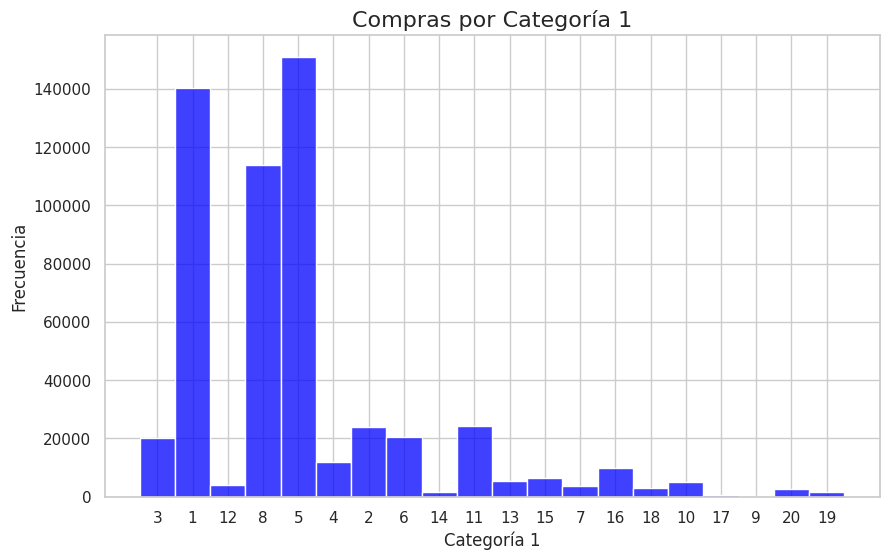

In [10]:
data['Categoria_1'] = data['Product_Category_1'].astype(str)

# --- Gráfico 1: Cantidad de compras según su frecuencia ---
plt.figure(figsize=(10, 6))
sns.histplot(data['Categoria_1'], 
             #kde=True, 
             #bins=50, 
             color='blue')
plt.title('Compras por Categoría 1', fontsize=16)
plt.xlabel('Categoría 1', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()


 # Gráfico 2: Compras por género

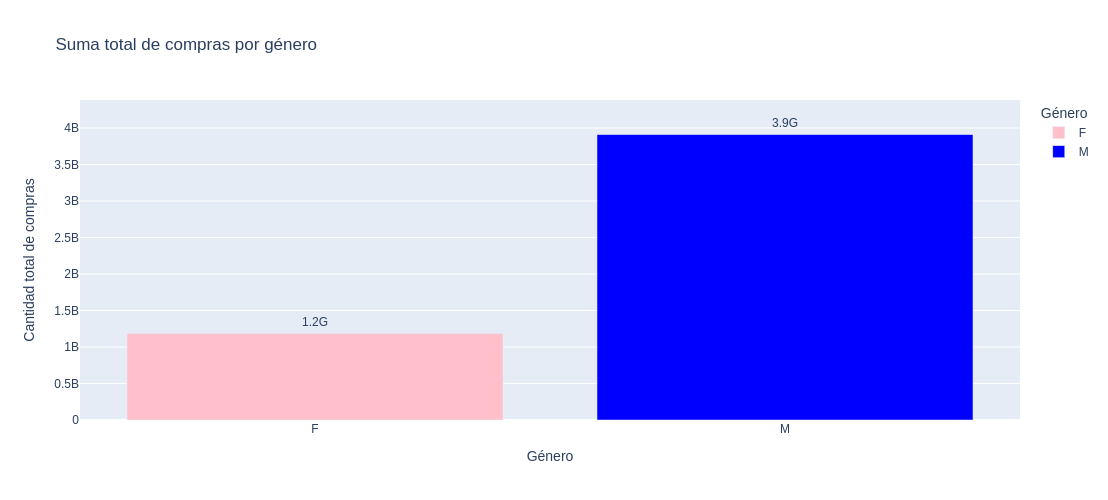

In [11]:
#Gráfico 2. Compras por género
import plotly.express as px


# Agrupar los datos por género y calcular la suma total de compras
gender_purchase = data.groupby('Gender', as_index=False)['Purchase'].sum()

# Crear el gráfico interactivo con Plotly
fig = px.bar(
    gender_purchase,
    x='Gender',
    y='Purchase',
    color='Gender',
    text='Purchase',
    title='Suma total de compras por género',
    labels={'Purchase': 'Cantidad total de compras', 'Gender': 'Género'},
    color_discrete_map={'M': 'blue', 'F': 'pink'}  # Asignar colores personalizados
)

# Ajustar las dimensiones
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(
    xaxis_title="Género",
    yaxis_title="Cantidad total de compras",
    uniformtext_minsize=8,
    uniformtext_mode='hide',
    width=800,  # Ancho del gráfico
    height=500  # Altura del gráfico
)

# Mostrar el gráfico interactivo
fig.show()


Las compras totales realizadas por hombres y mujeres, es decir clasificado por género influyen en el total de compras del Back Friday.
Al tratarse de un gráfico interactivo, puedes identificar los valores exactos de las compras.
La asignacion de colores facilita la distinción por generos y asi ofrece una visión más intuitiva.


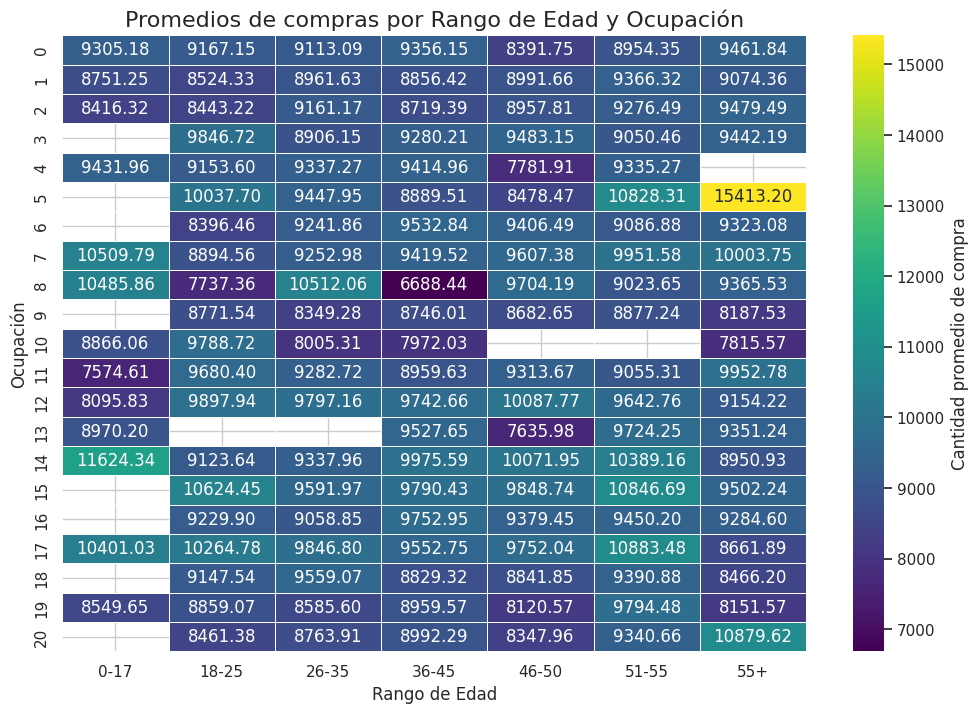

In [12]:
# --- Gráfico 3: Promedios de compras por rango de edad ---
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Crear la tabla dinámica con la media de compra por Edad y Ocupación
pivot_data = data.pivot_table(values='Purchase', index='Occupation', columns='Age', aggfunc=np.mean)

# Crear el heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_data, cmap='viridis', annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Cantidad promedio de compra'}, xticklabels=True, yticklabels=True)
plt.title('Promedios de compras por Rango de Edad y Ocupación', fontsize=16)
plt.xlabel('Rango de Edad', fontsize=12)
plt.ylabel('Ocupación', fontsize=12)
plt.show()

#### Gráficos adicionales para la explicación de la variable OCUPACIÓN

Para explicar mejor la funcionalidad de la varible 'Ocupación' en función del nivel de compras.



Text(0.5, 1.0, 'Grafico A - Cantidad de Personas por Ocupación')

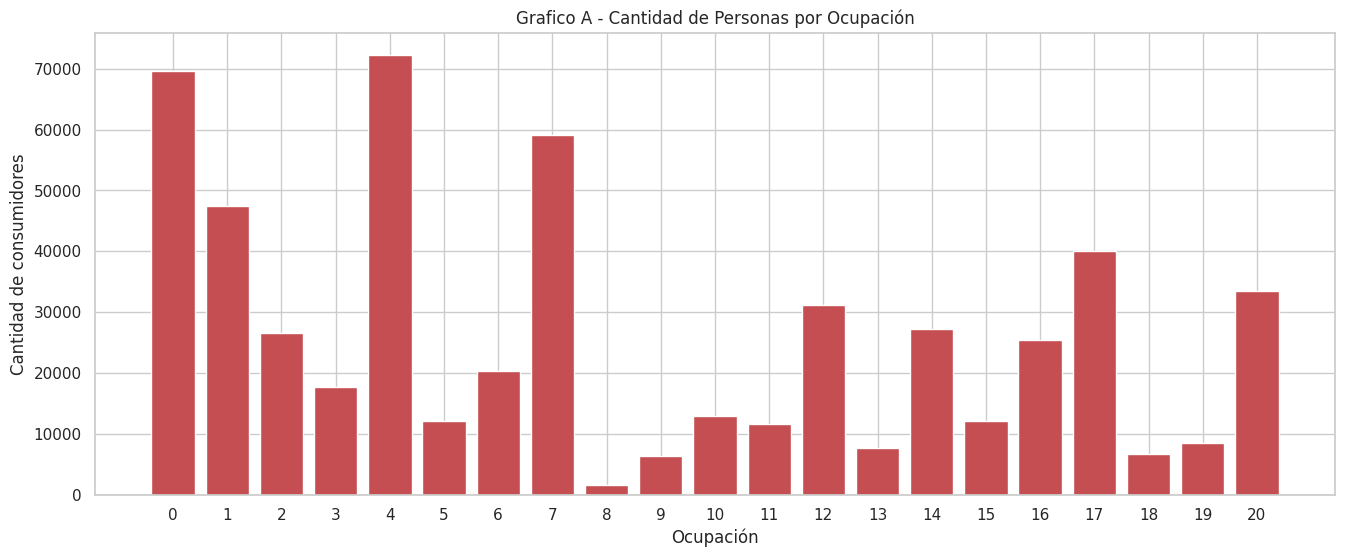

In [13]:
# Grafico A - Cantidad Personas por ocupación

ocupacion = blackfriday['Occupation'].value_counts();
plt.figure(figsize = (16,6));
plt.bar(ocupacion.index,ocupacion.values,color ='r');
plt.xticks(ocupacion.index);
plt.xlabel('Ocupación');
plt.ylabel('Cantidad de consumidores');
plt.title('Grafico A - Cantidad de Personas por Ocupación')

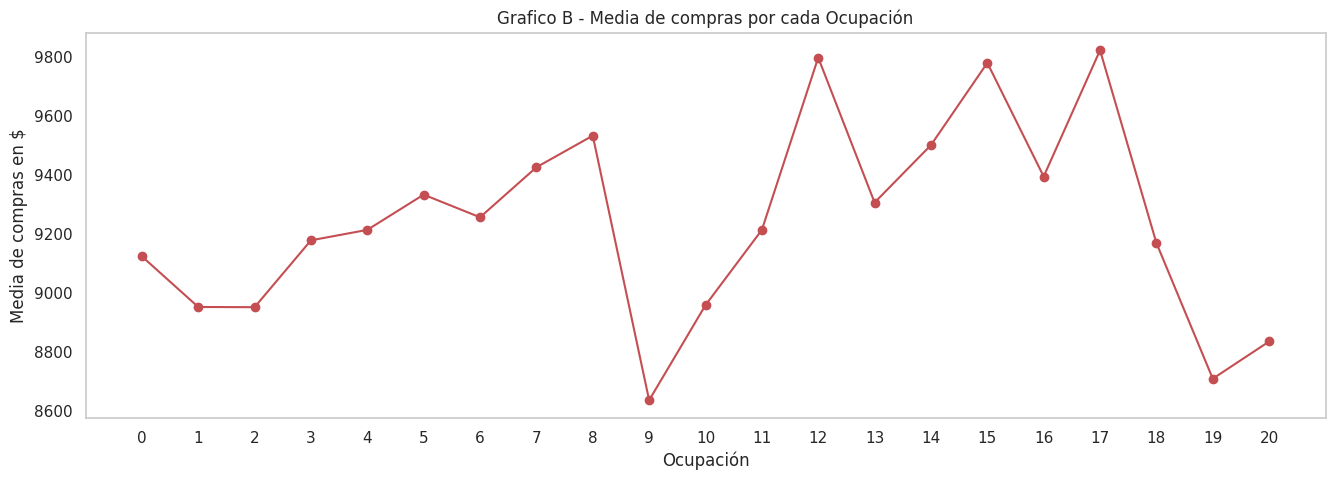

In [14]:
#Grafico B - Media de compras por Ocupación
data = blackfriday.groupby('Occupation')['Purchase'].mean();
plt.figure(figsize=(16,5));
plt.grid();
plt.plot(data.index,data.values,'ro-');
plt.xlabel('Ocupación');
plt.ylabel('Media de compras en $');
plt.title('Grafico B - Media de compras por cada Ocupación');
plt.xticks(data.index);